In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

plt.style.use('default')

## **Problem 1 to 2:**

**Dataset link:** https://rb.gy/gsmddu

**Add a label to every axis and add a proper title for the charts (For every subplot, it is applicable). Also add proper labels if there are multiple representations.** Then, you can customize it as your wish.

### **Problem-1:** Make a subplots which have 2 plots.

- For the first chart, draw a scatter plot "*Monitored Cap.(MW)*" vs "*Total Cap. Under Maintenance (MW)*" of top 5 most frequent power stations. Then draw the lines which indicate the average values of these two columns. Change the colors according to the names of the Power Stations.
- For the second chart, draw a scatter plot "*Monitored Cap. (MW)*" vs "*Actual(MU)*" of the top 5 most frequent power stations. Also draw the lines which indicates the average values of these two columns. Change the colors according to the names of the Power Stations.


In [2]:
df = pd.read_csv('datasets/PowerGeneration.csv')
df.head()

,Dates,Power Station,Monitored Cap.(MW),Total Cap. Under Maintenace (MW),Planned Maintanence (MW),Forced Maintanence(MW),Other Reasons (MW),Programme or Expected(MU),Actual(MU),Excess(+) / Shortfall (-),Deviation
0,2017-09-01,Delhi,2235.4,135.00,0.00,135.0,0,13,18,5.00,0.0
1,2017-09-01,Haryana,2720.0,2470.00,0.00,2470.0,0,28,7,-21.80,0.0
2,2017-09-01,Himachal Pradesh,3378.0,379.00,0.00,231.0,0,40,46,5.63,0.0
3,2017-09-01,Jammu and Kashmir,1285.0,150.00,0.00,0.0,0,14,23,9.43,0.0
4,2017-09-01,Punjab,3826.3,2697.65,77.65,2620.0,0,39,17,-21.69,0.0


In [3]:
most_freq_ps = df['Power Station'].value_counts().head().index.tolist()
most_freq_ps

['NTPC Ltd.', 'NHPC', 'NPCIL', 'GMR ENERG', 'APL']

In [4]:
temp_df = df[df['Power Station'].isin(most_freq_ps)]
temp_df

,Dates,Power Station,Monitored Cap.(MW),Total Cap. Under Maintenace (MW),Planned Maintanence (MW),Forced Maintanence(MW),Other Reasons (MW),Programme or Expected(MU),Actual(MU),Excess(+) / Shortfall (-),Deviation
11,2017-09-01,APL,1320.00,660.00,0.0,660.0,0,22,12,-10.62,0.0
28,2017-09-01,NHPC,4154.20,217.00,0.0,206.0,0,69,75,6.01,0.0
30,2017-09-01,NPCIL,1520.00,0.00,0.0,0.0,0,30,35,5.21,0.0
32,2017-09-01,NTPC Ltd.,12659.06,3364.66,710.0,995.0,0,182,162,-19.98,0.0
47,2017-09-01,APL,7920.00,2970.00,0.0,2970.0,0,122,95,-27.22,0.0
...,...,...,...,...,...,...,...,...,...,...,...
345246,2022-04-13,GMR ENERG,1050.00,0.00,0.0,0.0,0,0,25,2.53,0.0
345257,2022-04-13,NHPC,862.00,146.00,0.0,0.0,146,0,11,2.76,0.0
345260,2022-04-13,NTPC Ltd.,11730.00,1105.00,500.0,500.0,105,0,246,12.26,0.0
345270,2022-04-13,NHPC,105.00,35.00,0.0,35.0,0,0,0,-0.72,0.0


In [5]:
encoder = LabelEncoder()
encoder.fit_transform(temp_df['Power Station'])

array([0, 2, 3, ..., 4, 2, 4], shape=(30624,))

In [6]:
temp_df['Power Station'] = encoder.fit_transform(temp_df['Power Station'])
temp_df

C:\Users\Asus\AppData\Local\Temp\ipykernel_13820\1324191608.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df['Power Station'] = encoder.fit_transform(temp_df['Power Station'])


,Dates,Power Station,Monitored Cap.(MW),Total Cap. Under Maintenace (MW),Planned Maintanence (MW),Forced Maintanence(MW),Other Reasons (MW),Programme or Expected(MU),Actual(MU),Excess(+) / Shortfall (-),Deviation
11,2017-09-01,0,1320.00,660.00,0.0,660.0,0,22,12,-10.62,0.0
28,2017-09-01,2,4154.20,217.00,0.0,206.0,0,69,75,6.01,0.0
30,2017-09-01,3,1520.00,0.00,0.0,0.0,0,30,35,5.21,0.0
32,2017-09-01,4,12659.06,3364.66,710.0,995.0,0,182,162,-19.98,0.0
47,2017-09-01,0,7920.00,2970.00,0.0,2970.0,0,122,95,-27.22,0.0
...,...,...,...,...,...,...,...,...,...,...,...
345246,2022-04-13,1,1050.00,0.00,0.0,0.0,0,0,25,2.53,0.0
345257,2022-04-13,2,862.00,146.00,0.0,0.0,146,0,11,2.76,0.0
345260,2022-04-13,4,11730.00,1105.00,500.0,500.0,105,0,246,12.26,0.0
345270,2022-04-13,2,105.00,35.00,0.0,35.0,0,0,0,-0.72,0.0


Text(0.5, 1.0, 'Monitored Vs Actual(MU)')

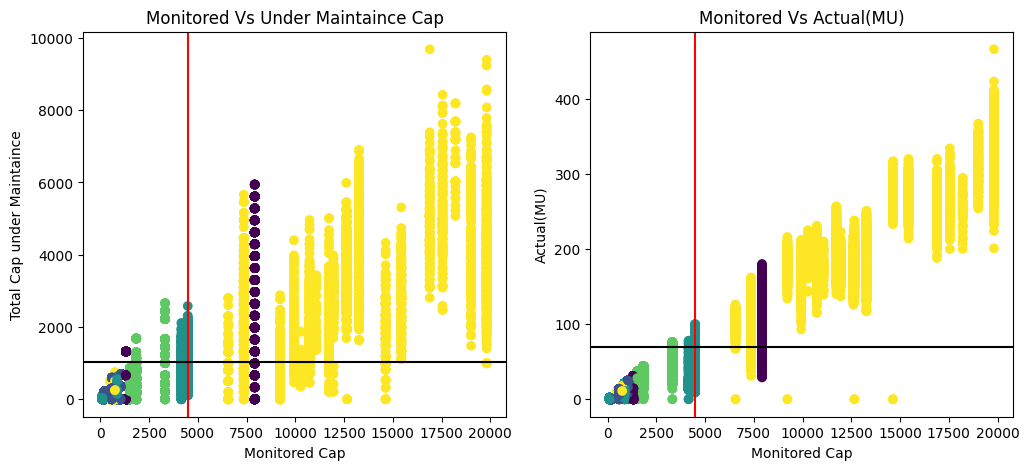

In [17]:
fig, ax = plt.subplots(1,2, figsize=(12,5))
ax[0].scatter(temp_df['Monitored Cap.(MW)'], temp_df['Total Cap. Under Maintenace (MW)'], c=temp_df['Power Station'])
ax[0].axvline(temp_df['Monitored Cap.(MW)'].mean(), c='red')
ax[0].axhline(temp_df['Total Cap. Under Maintenace (MW)'].mean(), c='black')
ax[0].set_xlabel('Monitored Cap')
ax[0].set_ylabel('Total Cap under Maintaince')
ax[0].set_title('Monitored Vs Under Maintaince Cap')



ax[1].scatter(temp_df['Monitored Cap.(MW)'], temp_df['Actual(MU)'], c=temp_df['Power Station'])
ax[1].axvline(temp_df['Monitored Cap.(MW)'].mean(), c='red')
ax[1].axhline(temp_df['Actual(MU)'].mean(), c='black')
ax[1].set_xlabel('Monitored Cap')
ax[1].set_ylabel('Actual(MU)')
ax[1].set_title('Monitored Vs Actual(MU)')

### **Problem-2:** Draw a 3D Scatter plot between "*Monitored Cap.(MW)*", "*Total Cap. Under Maintenace (MW)*" and "*Forced Maintanence(MW)*"

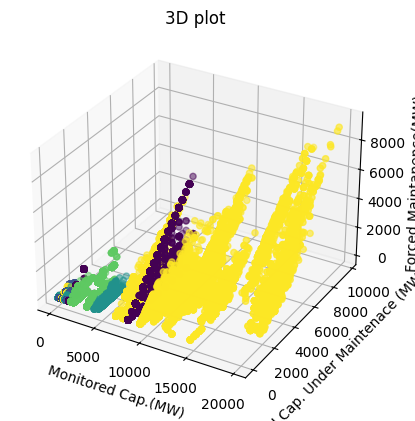

In [22]:
fig = plt.figure()

ax = plt.subplot(projection='3d')

ax.scatter3D(temp_df['Monitored Cap.(MW)'], temp_df['Total Cap. Under Maintenace (MW)'], temp_df['Forced Maintanence(MW)'], c=temp_df['Power Station'])
ax.set_xlabel('Monitored Cap.(MW)')
ax.set_ylabel('Total Cap. Under Maintenace (MW)')
ax.set_zlabel('Forced Maintanence(MW)')
ax.set_title('3D plot')
plt.show()

### **Problem-3:** Make a 3D *Surface* plot of this below mathematical equation.

$$z = |x| - |y|$$

In [23]:
x = np.linspace(-10,10,100)
y = np.linspace(-10,10,100)

xx, yy = np.meshgrid(x,y)

z = np.abs(xx) - np.abs(yy)

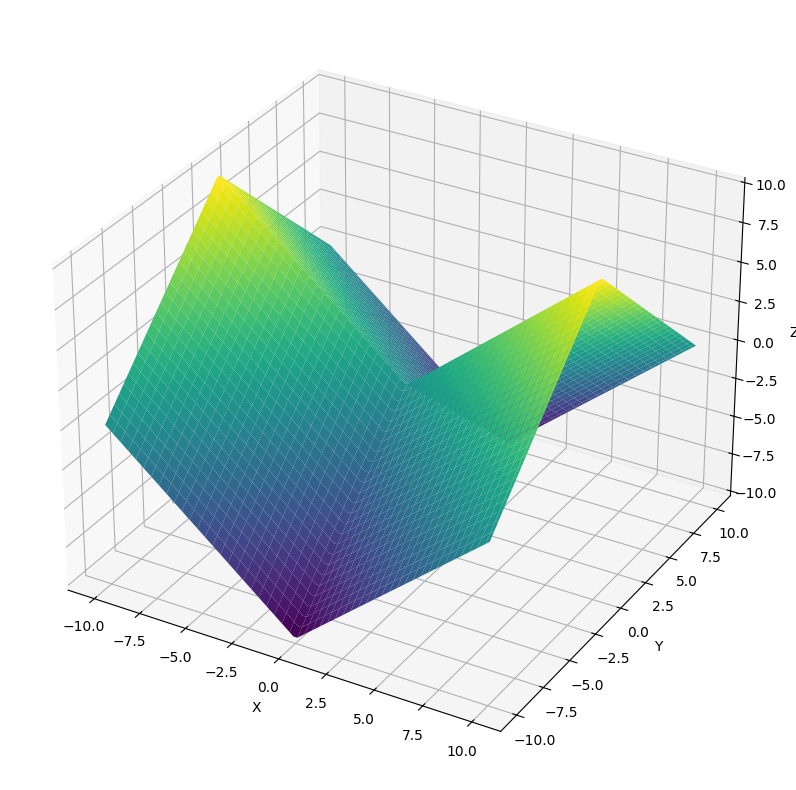

In [25]:
fig = plt.figure(figsize=(10,10))

ax = plt.subplot(projection='3d')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

ax.plot_surface(xx,yy,z, cmap='viridis')

plt.show()

### **Problem-4:** Draw the 3D *Contour plot* of this below equation:

$$z = |x| - |y|$$

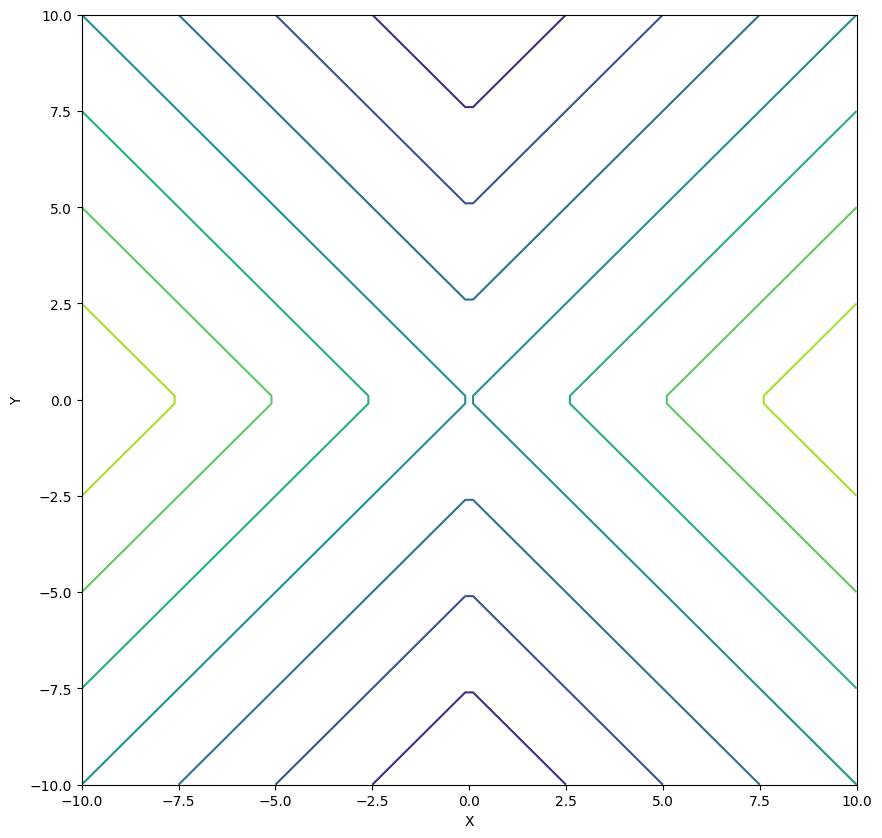

In [30]:
fig = plt.figure(figsize=(10,10))

ax = plt.subplot()
ax.contour(xx,yy,z, cmap='viridis')
ax.set_xlabel('X')
ax.set_ylabel('Y')

plt.show()

### **Problem-5:** Draw a second type of Countour plot of the below equation:

$$z = |x| - |y|$$

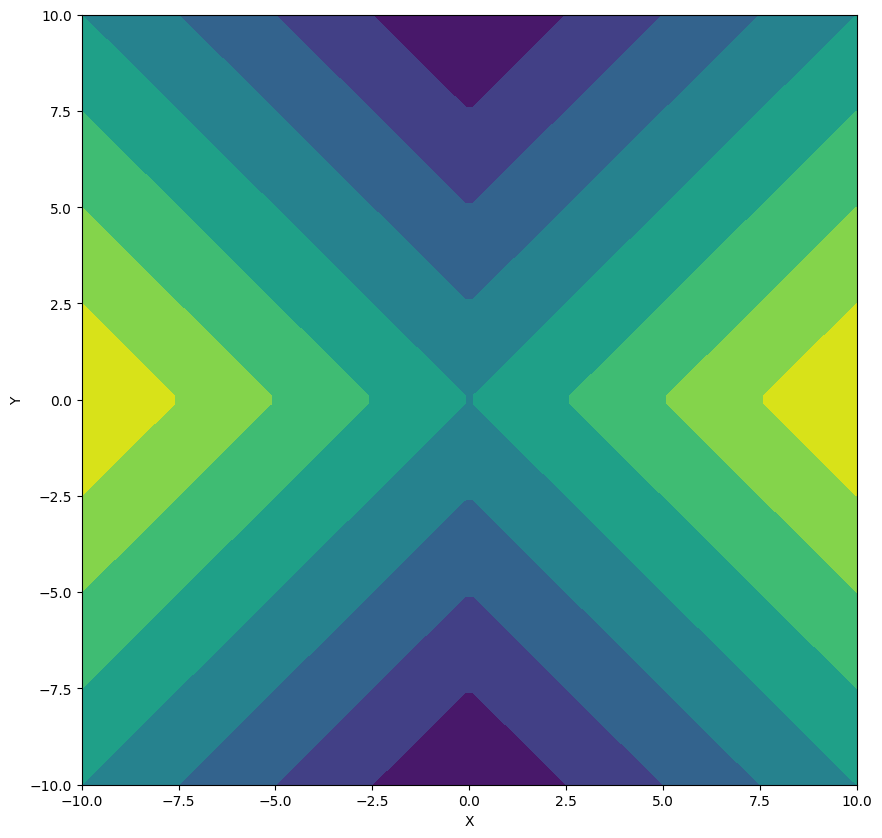

In [31]:
fig = plt.figure(figsize=(10,10))

ax = plt.subplot()
ax.contourf(xx,yy,z, cmap='viridis')
ax.set_xlabel('X')
ax.set_ylabel('Y')

plt.show()

## `Problem 6-7`

Data Set Link - https://docs.google.com/spreadsheets/d/17tUL2yC7MGvo7txuuhLtAI-b6_C4jc0t7FLFxqRm-uI/edit?usp=share_link


**Description of Dataset:**

* Date: It gives the date of which stocks details are given.
* Symbol: Name of stock
* Open: It gives the opening price of stock on that date.
* High: It gives the highest price to which the stock ascened on that day.
* Low: It gives the highest price to which the stock plummeted on that day.
* Close: It gives the closing price of stock on that date.
* Volume: It gives the amount of stock traded on that date.
* VWAP: The volume-weighted average price (VWAP) is a statistic used by traders to determine what the average price is based on both price and volume.
* Turnover:

### `Problem-6` Use Pandas plot functions

* Line plot of closing value of top 5 Stocks in Year 2020.
* Take top 5 stocks based on total turnover in Year 2020

In [ ]:
# code here

### `Problem-7` Scatter plot Close price vs Volume for TOP-5 Stocks in year 2021
* Color on Symbol Column

In [ ]:
# code here

### `Problem-8` Create a 3-D Scatter Plot using `time,x,y` on below synthetic data. and give color gradiant on `z`
```
# Create a 3D dataset
time = np.linspace(0, 10, 100)
x = np.sin(time)
y = np.cos(time)
z = time

# Create a DataFrame from the dataset
data = pd.DataFrame({'time': time, 'x': x, 'y': y, 'z': z})
```

In [ ]:
# code here

### `Problem 9:` Create a surface plot and the 2 types of the contour plots of the below equation.

$$z = sin(\sqrt{x^2 + y^2})$$


In [ ]:
# code here

### `Problem 10:` Create a surface plot and the 2 types of the contour plots of the below equation.

$$z = tan(\log_2({x^2 + y^2})$$

In [ ]:
# code here